=== DATA SETUP ===
Loaded lifted states shape: (1000, 38)
Total time steps: 1000 | Total lifted dimensions: 38

=== KOOPMAN TRAINING (RIDGE EDMD) ===
Koopman operator matrix K shape: (38, 38)
=== KOOPMAN SPECTRUM ANALYSIS ===
Total Eigenvalues: 38
Max Eigenvalue (Complex): 1.00002 + 0.00021j
Max Eigenvalue Magnitude: 1.00002


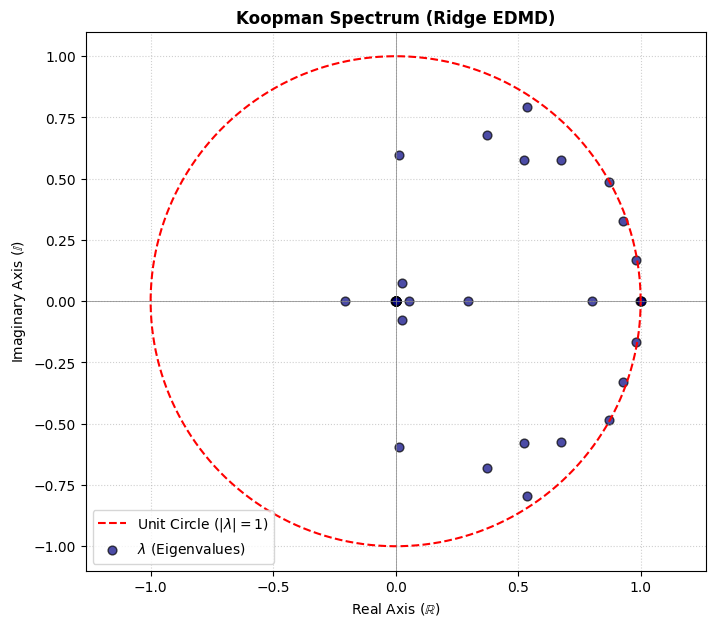

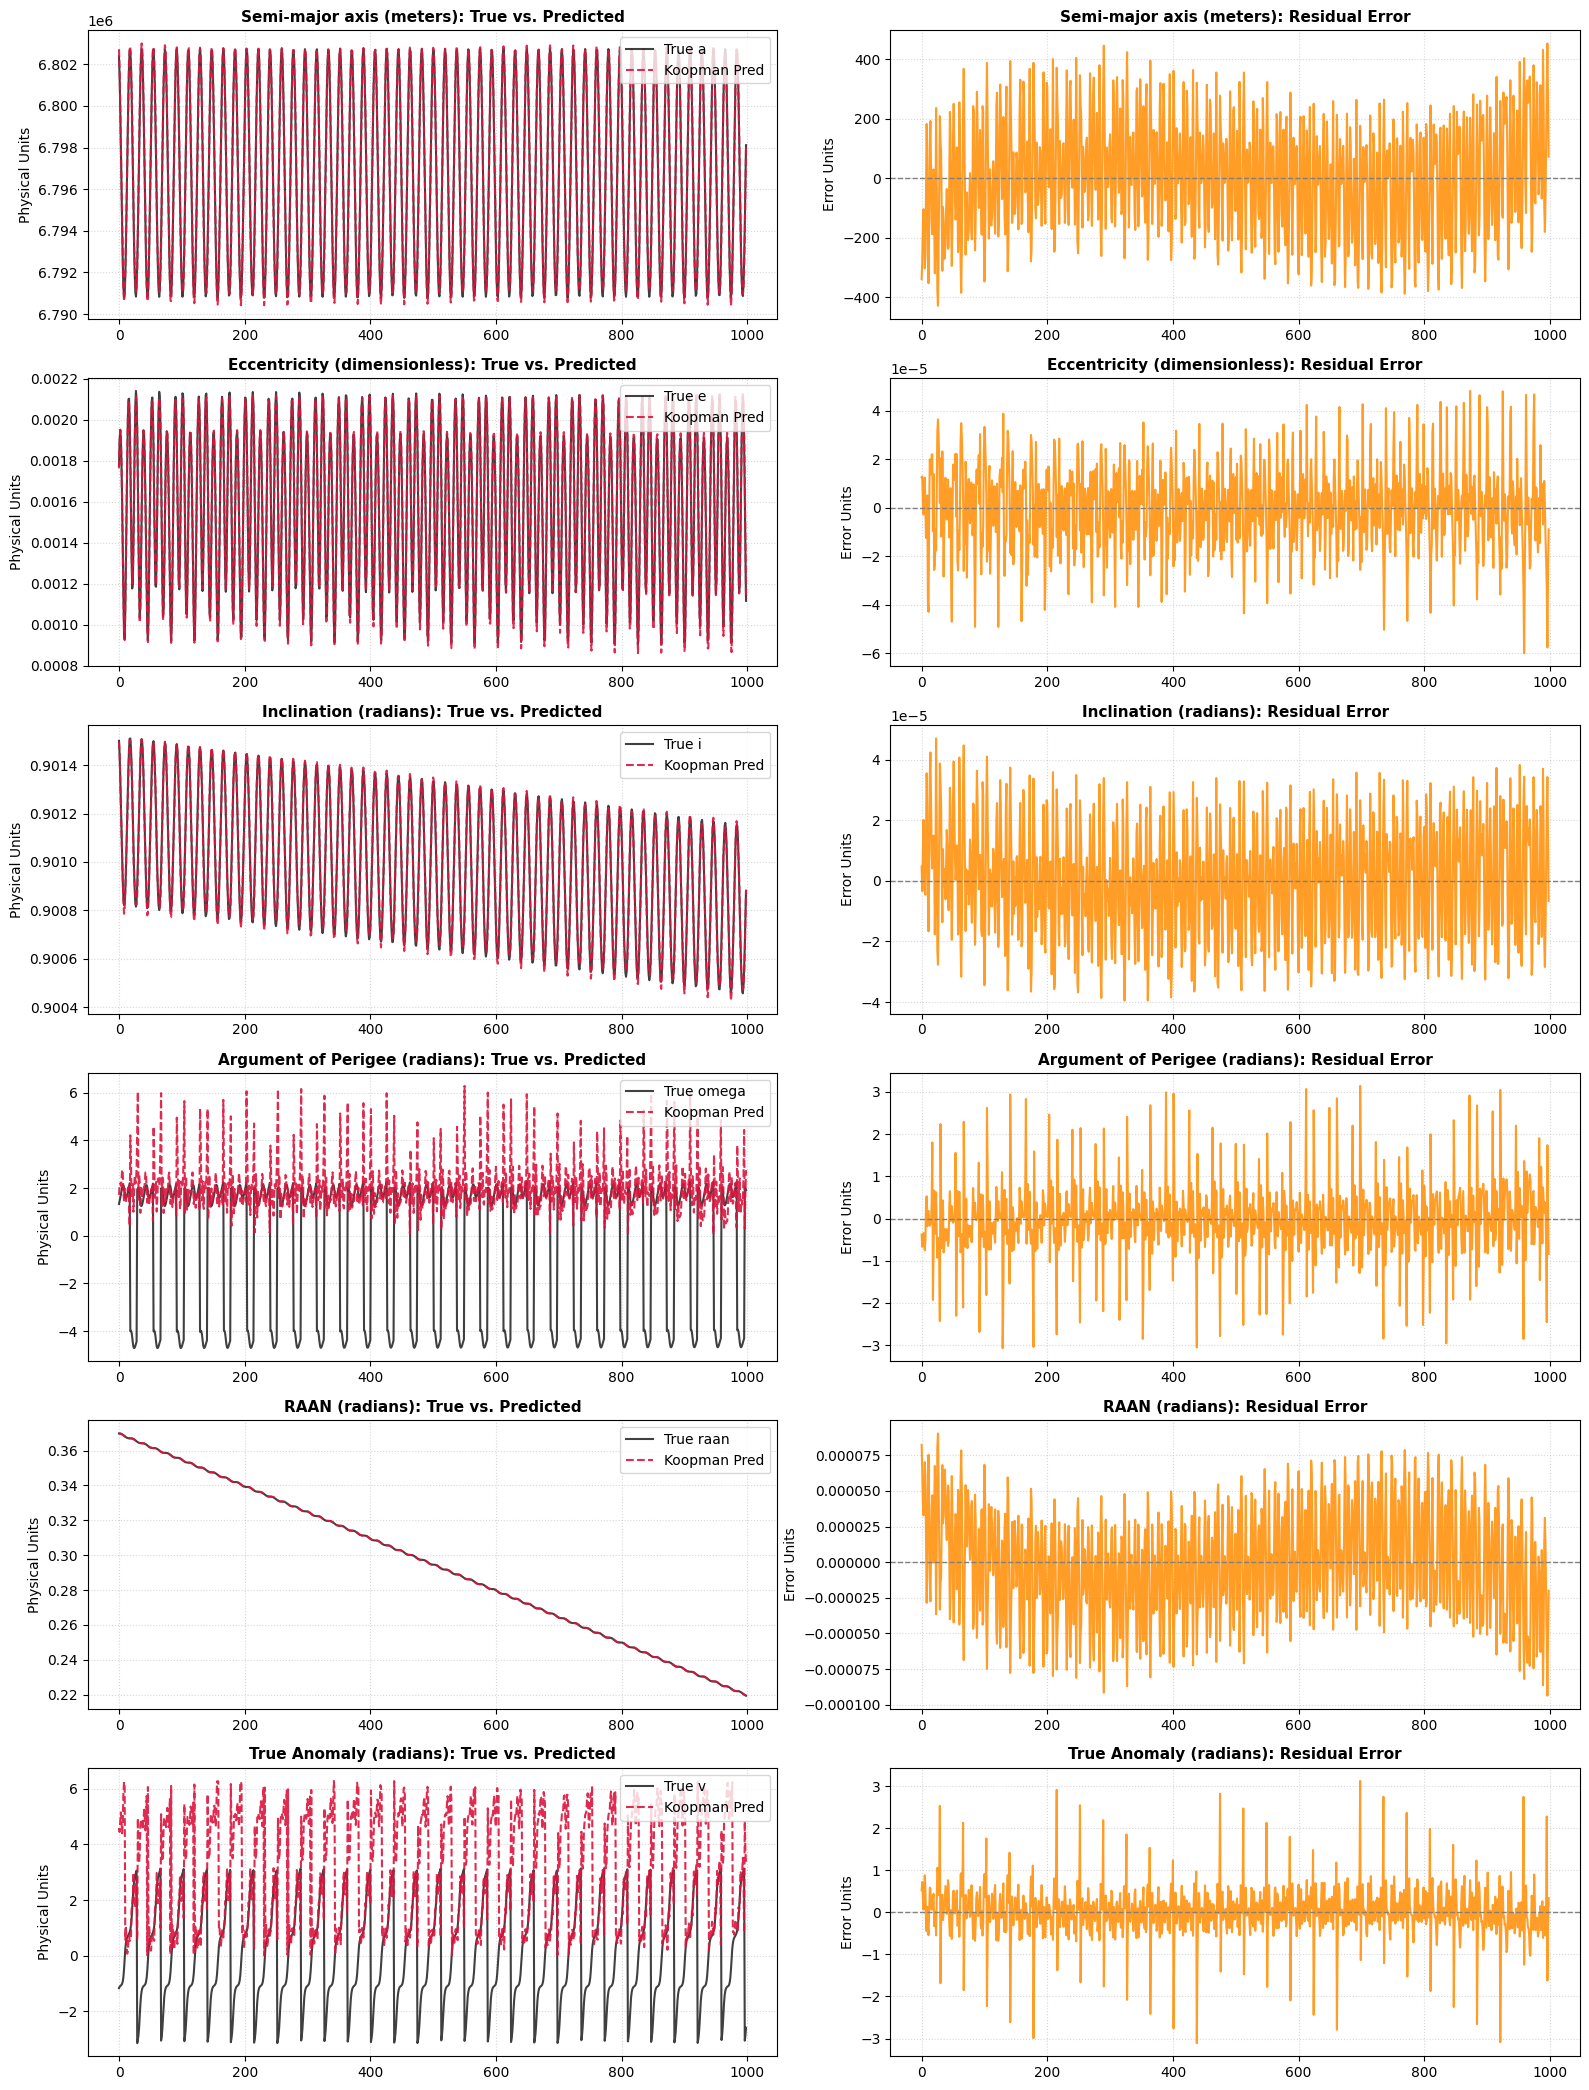

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler

# ==============================================================================
# 1. DATA LOADING & PREPARATION (TRAINING PHASE)
# ==============================================================================
try:
    df_raw = pd.read_csv('raw_orbit_data.csv')
    df_lifted = pd.read_csv("lifted_orbit_data.csv")
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"Missing data file: {e}. Ensure both 'raw_orbit_data.csv' and "
        "'lifted_orbit_data.csv' are in your working directory."
    )


# Re-fit the exact same scaler used in lifting code to perform inverse transform for a and e
scaler_ae = MinMaxScaler(feature_range=(-1, 1))
scaler_ae.fit(df_raw[['a', 'e']])



Z = df_lifted.values  # These are your 'lifted' dictionary states \psi(x)
n_samples, n_dim = Z.shape

# Shift data to align Before (Z1 at time k) and After (Z2 at time k+1)
Z1 = Z[:-1]
Z2 = Z[1:]

print(f"=== DATA SETUP ===")
print(f"Loaded lifted states shape: {Z.shape}")
print(f"Total time steps: {n_samples} | Total lifted dimensions: {n_dim}\n")


# ==============================================================================
# 2. TRAIN KOOPMAN OPERATOR (RIDGE EDMD FOR OPTIMAL 1-STEP MAPPING)
# ==============================================================================
# alpha=1e-4 adds a small penalty to keep the weights of your features stable
model = Ridge(alpha=1e-4, fit_intercept=False)
model.fit(Z1, Z2)

# Extract the Koopman Operator matrix K
K = model.coef_

print(f"=== KOOPMAN TRAINING (RIDGE EDMD) ===")
print(f"Koopman operator matrix K shape: {K.shape}")

# Predict Z2 (one-step ahead) in lifted space
Z2_pred = Z1 @ K.T


# ==============================================================================
# 3. POST-PROCESSING: UNLIFTING TO ORIGINAL RAW DOMAIN (RADIANS)
# ==============================================================================
# Extract the true raw values directly from df_raw (matching time k+1)
true_raw_orbit = df_raw.iloc[1:].copy().reset_index(drop=True) 

# Map the first 6 columns of your predicted lifted matrix back to base variables
pred_raw_orbit = pd.DataFrame(Z2_pred[:, 1:7], columns=['a', 'e', 'i', 'omega', 'raan', 'v'])

# 1. Invert the scaling for semi-major axis and eccentricity
pred_raw_orbit[['a', 'e']] = scaler_ae.inverse_transform(pred_raw_orbit[['a', 'e']])

# 2. Keep the angles in their raw unlifted domain (radians)
# Optional: Apply a modulo 2*pi wrap to the predictions to prevent unphysical angle drifting
angles = ['i', 'omega', 'raan', 'v']
pred_raw_orbit[angles] = pred_raw_orbit[angles] % (2 * np.pi)



#==============================================================================
# 4. DIAGNOSTIC DASHBOARD VISUALIZATION
# ==============================================================================

# --- Figure 1: Koopman Spectrum Analysis (RE-ADDED) ---
eigvals, _ = np.linalg.eig(K)

# Calculate magnitudes to find the dominant eigenvalue
magnitudes = np.abs(eigvals)
max_idx = np.argmax(magnitudes)
max_eigval = eigvals[max_idx]
max_magnitude = magnitudes[max_idx]

# Print the maximum eigenvalue metrics to the console
print(f"=== KOOPMAN SPECTRUM ANALYSIS ===")
print(f"Total Eigenvalues: {len(eigvals)}")
print(f"Max Eigenvalue (Complex): {max_eigval.real:.5f} + {max_eigval.imag:.5f}j")
print(f"Max Eigenvalue Magnitude: {max_magnitude:.5f}")

plt.figure(figsize=(8, 7))
theta = np.linspace(0, 2 * np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), 'r--', linewidth=1.5, label='Unit Circle ($|\lambda|=1$)')
plt.scatter(eigvals.real, eigvals.imag, color='navy', alpha=0.7, edgecolors='k', s=40, label='$\lambda$ (Eigenvalues)')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.title("Koopman Spectrum (Ridge EDMD)", fontsize=12, fontweight='bold')
plt.xlabel("Real Axis ($\mathbb{R}$)")
plt.ylabel("Imaginary Axis ($\mathbb{I}$)")
plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left')
plt.show()

# --- Figure 2: Dynamic Tracking & Error in RAW Physical Domain ---
feature_names = {
    'a': 'Semi-major axis (meters)',
    'e': 'Eccentricity (dimensionless)',
    'i': 'Inclination (radians)',
    'omega': 'Argument of Perigee (radians)',
    'raan': 'RAAN (radians)',
    'v': 'True Anomaly (radians)'
}

fig, axes = plt.subplots(len(feature_names), 2, figsize=(16, 3.5 * len(feature_names)))

for i, col in enumerate(feature_names.keys()):
    name = feature_names[col]
    
    true_vals = true_raw_orbit[col].values
    pred_vals = pred_raw_orbit[col].values
    
    # Calculate geometric residual error (handles modular wrap-around for angles)
    # This prevents artificial vertical error spikes when angles wrap between 0 and 2*pi
    if col in angles:
        error_vals = np.arctan2(np.sin(true_vals - pred_vals), np.cos(true_vals - pred_vals))
    else:
        error_vals = true_vals - pred_vals
    
    # Left Column: Raw Space Tracking
    ax_comp = axes[i, 0]
    ax_comp.plot(true_vals, label=f"True {col}", color='black', alpha=0.75, linewidth=1.5)
    ax_comp.plot(pred_vals, '--', label=f"Koopman Pred", color='crimson', alpha=0.9, linewidth=1.5)
    ax_comp.set_title(f"{name}: True vs. Predicted", fontsize=11, fontweight='bold')
    ax_comp.set_ylabel("Physical Units")
    ax_comp.grid(True, linestyle=':', alpha=0.5)
    ax_comp.legend(loc='upper right')
    
    # Right Column: Residuals
    ax_err = axes[i, 1]
    ax_err.plot(error_vals, color='darkorange', alpha=0.85)
    ax_err.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax_err.set_title(f"{name}: Residual Error", fontsize=11, fontweight='bold')
    ax_err.set_ylabel("Error Units")
    ax_err.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()